In [141]:
# Import

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/tickets.csv")

print("Shape:", df.shape)
df.head()

Shape: (8469, 17)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Category,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,22-03-2021,Technical issue,Product setup,"I'm having an issue with the {product_purchased}. Please assist.\n\nYour billing zip code is: 71701.\n\nWe appreciate that you have requested a website address.\n\nPlease double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.",Pending Customer Response,NaN,Critical,Social media,01-06-2023 12:15,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,22-05-2021,Technical issue,Peripheral compatibility,"I'm having an issue with the {product_purchased}. Please assist.\n\nIf you need to change an existing product.\n\nI'm having an issue with the {product_purchased}. Please assist.\n\nIf The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly.",Pending Customer Response,NaN,Critical,Chat,01-06-2023 16:45,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,14-07-2020,Technical issue,Network problem,"I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond.\n\n1.8.3 I really I'm using the original charger that came with my {product_purchased}, but it's not charging properly.",Closed,Case maybe show recently my computer follow.,Low,Social media,01-06-2023 11:14,01-06-2023 18:05,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,13-11-2020,Billing inquiry,Account access,"I'm having an issue with the {product_purchased}. Please assist.\n\nIf you have a problem you're interested in and I'd love to see this happen, please check out the Feedback. I've already contacted customer support multiple times, but the issue remains unresolved.",Closed,Try capital clearly never color toward story.,Low,Social media,01-06-2023 07:29,01-06-2023 01:57,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,04-02-2020,Billing inquiry,Data loss,I'm having an issue with the {product_purchased}. Please assist.\n\n\nNote: The seller is not responsible for any damages arising out of the delivery of the battleground game. Please have the game in good condition and shipped to you I've noticed a sudden decrease in battery life on my {product_...,Closed,West decision evidence bit.,Low,Email,01-06-2023 00:12,01-06-2023 19:53,1.0


In [142]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Category               8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 non-null   str    
 13  Ticket Channel

In [143]:
# Missing values

missing = df.isnull().sum()

missing = missing[
    missing > 0
].sort_values(
    ascending=False
)

missing

Resolution                      5700
Time to Resolution              5700
Customer Satisfaction Rating    5700
First Response Time             2819
dtype: int64

In [144]:
# Duplicate rows

print(
    "Duplicate rows:",
    df.duplicated().sum()
)

print(
    "Duplicate Ticket IDs:",
    df["Ticket ID"].duplicated().sum()
)

Duplicate rows: 0
Duplicate Ticket IDs: 0


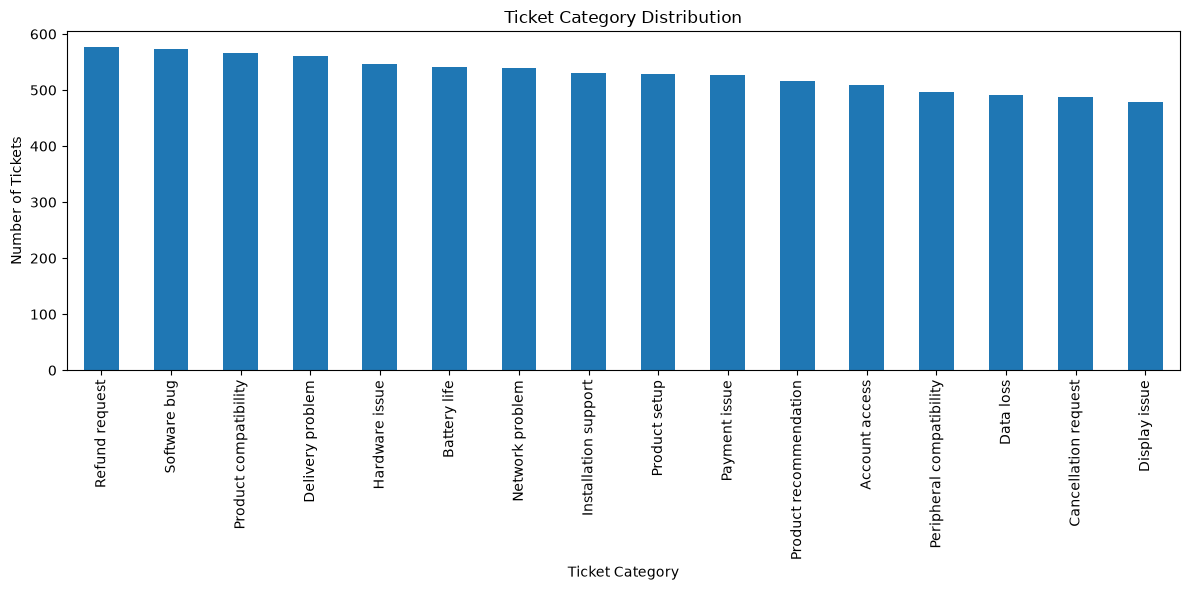

In [145]:
# Ticket Category distribution

plt.figure(figsize=(12, 6))

category_counts.plot(kind="bar")

plt.title("Ticket Category Distribution")
plt.xlabel("Ticket Category")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "../screenshots/category_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [146]:
# Ticket Type distribution

df["Ticket Type"].value_counts()

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

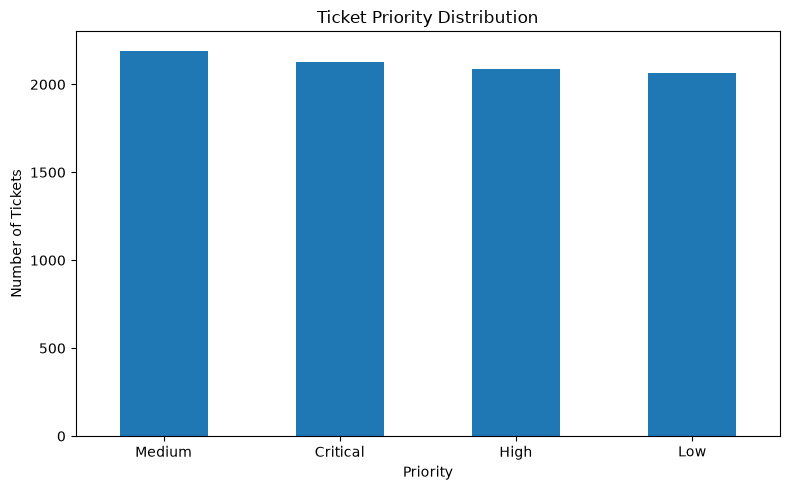

In [160]:
plt.figure(figsize=(8, 5))

priority_counts.plot(kind="bar")

plt.title("Ticket Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../screenshots/priority_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [148]:
# Text preprocessing

import sys

sys.path.append("../src")

from preprocessing import clean_text

df["Cleaned Description"] = (
    df["Ticket Description"]
    .apply(clean_text)
)

df[
    [
        "Ticket Description",
        "Cleaned Description"
    ]
].head(10)

,Ticket Description,Cleaned Description
0,"I'm having an issue with the {product_purchased}. Please assist.\n\nYour billing zip code is: 71701.\n\nWe appreciate that you have requested a website address.\n\nPlease double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.",im having an issue with the please assist your billing zip code is 71701 we appreciate that you have requested a website address please double check your email address ive tried troubleshooting steps mentioned in the user manual but the issue persists
1,"I'm having an issue with the {product_purchased}. Please assist.\n\nIf you need to change an existing product.\n\nI'm having an issue with the {product_purchased}. Please assist.\n\nIf The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly.",im having an issue with the please assist if you need to change an existing product im having an issue with the please assist if the issue im facing is intermittent sometimes it works fine but other times it acts up unexpectedly
2,"I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond.\n\n1.8.3 I really I'm using the original charger that came with my {product_purchased}, but it's not charging properly.",im facing a problem with my the is not turning on it was working fine until yesterday but now it doesnt respond 1 8 3 i really im using the original charger that came with my but its not charging properly
3,"I'm having an issue with the {product_purchased}. Please assist.\n\nIf you have a problem you're interested in and I'd love to see this happen, please check out the Feedback. I've already contacted customer support multiple times, but the issue remains unresolved.",im having an issue with the please assist if you have a problem youre interested in and id love to see this happen please check out the feedback ive already contacted customer support multiple times but the issue remains unresolved
4,I'm having an issue with the {product_purchased}. Please assist.\n\n\nNote: The seller is not responsible for any damages arising out of the delivery of the battleground game. Please have the game in good condition and shipped to you I've noticed a sudden decrease in battery life on my {product_...,im having an issue with the please assist note the seller is not responsible for any damages arising out of the delivery of the battleground game please have the game in good condition and shipped to you ive noticed a sudden decrease in battery life on my it used to last much longer
5,"I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond. To remove the new {product_purch I've checked for any available software updates for my {product_purchased}, but there are none.",im facing a problem with my the is not turning on it was working fine until yesterday but now it doesnt respond to remove the new but there are none
6,"I'm unable to access my {product_purchased} account. It keeps displaying an 'Invalid Credentials' error, even though I'm using the correct login information. How can I regain access to my account?\n\nSolution 1 I'm unable to find the option to perform the desired action in the {product_purchased...",im unable to access my account it keeps displaying an invalid credentials error even though im using the correct login information how can i regain access to my account solution 1 im unable to find the option to perform the desired action in the could you please guide me through the steps
7,"I'm having an issue with the {product_purchased}. Please assist. (Thanks) I will contact all my suppliers and confirm.\n\nPlease try and find out whether their inventory is currently stocked, or any other reason. I am I've performed a factory reset on my {product_purchased}, hopi

In [149]:
# Empty descriptions

empty_count = (
    df["Cleaned Description"]
    .eq("")
    .sum()
)

print(
    "Empty cleaned descriptions:",
    empty_count
)

Empty cleaned descriptions: 0


In [150]:
# Duplicate description analysis

duplicate_descriptions = (
    df["Cleaned Description"]
    .duplicated()
    .sum()
)

print(
    "Duplicate descriptions:",
    duplicate_descriptions
)

description_counts = (
    df["Cleaned Description"]
    .value_counts()
)

description_counts.head(20)


Duplicate descriptions: 461


Cleaned Description
im having an issue with the please assist ive already contacted customer support multiple times but the issue remains unresolved                                 29
im having an issue with the please assist ive noticed a peculiar error message popping up on my screen it says what does it mean                                 28
im having an issue with the please assist this problem started occurring after the recent software update i haven t made any other changes to the device         27
im having an issue with the please assist i need assistance as soon as possible because its affecting my work and productivity                                   26
im having an issue with the please assist im concerned about the security of my and would like to ensure that my data is safe                                    25
im having an issue with the please assist ive performed a factory reset on my hoping it would resolve the problem but it didnt help                             

In [151]:
# Same description → multiple categories

description_category_counts = (
    df.groupby(
        "Cleaned Description"
    )["Ticket Category"]
    .nunique()
)

multi_category = (
    description_category_counts > 1
)

print(
    "Descriptions associated with multiple categories:",
    multi_category.sum()
)


multi_category_descriptions = (
    description_category_counts[
        multi_category
    ]
)

multi_category_descriptions.head(20)

Descriptions associated with multiple categories: 64


Cleaned Description
im facing issues logging into my account it says my account is locked what should i do to unlock it im worried that the issue might be hardware related and might require repair or replacement                                   2
im facing issues logging into my account it says my account is locked what should i do to unlock it ive already contacted customer support multiple times but the issue remains unresolved                                        2
im having an issue with the please assist but the issue persists                                                                                                                                                                  3
im having an issue with the please assist hoping it would resolve the problem but it didnt help                                                                                                                                   2
im having an issue with the please assist i need assistance as soon 

In [152]:
# Keyword analysis

keywords = [
    "battery",
    "refund",
    "password",
    "network",
    "delivery",
    "payment"
]

for keyword in keywords:

    print("=" * 60)
    print("Keyword:", keyword)

    mask = (
        df["Cleaned Description"]
        .str.contains(
            keyword,
            case=False,
            na=False
        )
    )

    counts = (
        df.loc[
            mask,
            "Ticket Category"
        ]
        .value_counts()
    )

    percentages = (
        counts /
        counts.sum() *
        100
    ).round(2)

    result = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages
    })

    print(
        "Total occurrences:",
        mask.sum()
    )

    print(result)

Keyword: battery
Total occurrences: 285
                          Count  Percentage
Ticket Category                            
Refund request               22        7.72
Payment issue                22        7.72
Delivery problem             22        7.72
Display issue                21        7.37
Software bug                 21        7.37
Peripheral compatibility     19        6.67
Product recommendation       18        6.32
Product compatibility        18        6.32
Hardware issue               18        6.32
Installation support         17        5.96
Product setup                16        5.61
Account access               16        5.61
Battery life                 16        5.61
Data loss                    14        4.91
Cancellation request         13        4.56
Network problem              12        4.21
Keyword: refund
Total occurrences: 158
                          Count  Percentage
Ticket Category                            
Peripheral compatibility     14        8.

In [153]:
# Ticket Type × Ticket Category

cross_table = pd.crosstab(
    df["Ticket Type"],
    df["Ticket Category"]
)

cross_table

Ticket Category,Account access,Battery life,Cancellation request,Data loss,Delivery problem,Display issue,Hardware issue,Installation support,Network problem,Payment issue,Peripheral compatibility,Product compatibility,Product recommendation,Product setup,Refund request,Software bug
Ticket Type,,,,,,,,,,,,,,,,
Billing inquiry,103,106,82,89,115,91,100,108,95,107,94,123,95,104,100,122
Cancellation request,92,104,103,115,114,103,109,99,102,113,102,97,98,108,126,110
Product inquiry,107,101,85,91,109,80,106,99,113,91,93,121,111,100,122,112
Refund request,108,119,109,97,107,99,129,119,107,104,106,107,106,104,119,112
Technical issue,99,112,108,99,116,105,103,105,122,111,101,119,107,113,109,118


In [154]:
# Baseline calculation

number_of_categories = (
    df["Ticket Category"]
    .nunique()
)

random_baseline = (
    1 / number_of_categories
)

majority_count = (
    df["Ticket Category"]
    .value_counts()
    .iloc[0]
)

majority_baseline = (
    majority_count /
    len(df)
)

print(
    "Number of categories:",
    number_of_categories
)

print(
    "Random baseline:",
    random_baseline
)

print(
    "Majority baseline:",
    majority_baseline
)

Number of categories: 16
Random baseline: 0.0625
Majority baseline: 0.06801275239107332


In [155]:
X = df["Cleaned Description"]
y = df["Ticket Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

In [156]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test, y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_test, y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_test, y_pred,
    average="macro",
    zero_division=0
)

print("Ticket Category Model Performance")
print("-" * 40)
print(f"Accuracy : {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision * 100:.2f}%)")
print(f"Recall   : {recall:.4f} ({recall * 100:.2f}%)")
print(f"F1 Score : {f1:.4f} ({f1 * 100:.2f}%)")

Ticket Category Model Performance
----------------------------------------
Accuracy : 0.0667 (6.67%)
Precision: 0.0666 (6.66%)
Recall   : 0.0656 (6.56%)
F1 Score : 0.0645 (6.45%)
